Saving DEG COPD- Merged.xlsx to DEG COPD- Merged (2).xlsx
Columns found:
['Gene', 'logFC', 't', 'P.value', 'AvgExp', 'nan', 'adj. P. Val']

DEG SUMMARY
Upregulated : 167
Downregulated : 32
Total Significant DEGs : 199


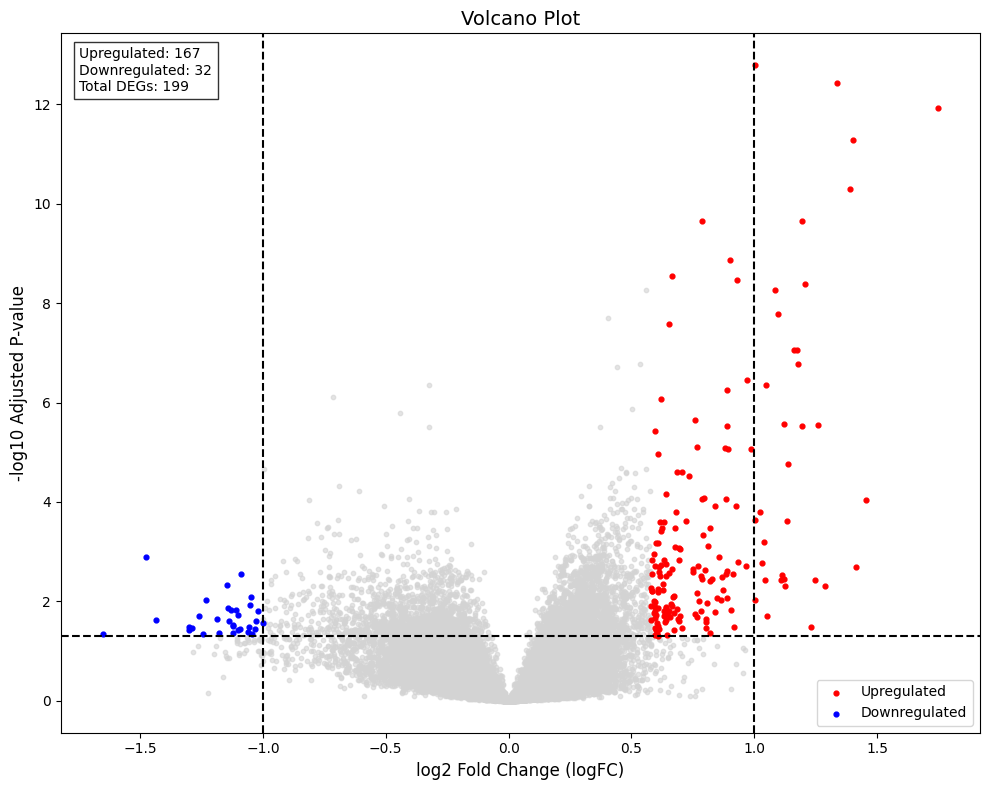


Files saved:
1. Volcano_Plot.png
2. Significant_DEGs.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================
# Install required packages
# ==========================
!pip install pandas matplotlib openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==========================
# Upload Excel file
# ==========================
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# ==========================
# Read Excel file
# ==========================
df = pd.read_excel(filename)

# Clean column names
df.columns = df.columns.astype(str).str.strip()

print("Columns found:")
print(df.columns.tolist())

# ==========================
# Your column names
# ==========================
logfc_col = "logFC"
padj_col = "adj. P. Val"

# Convert to numeric
df[logfc_col] = pd.to_numeric(df[logfc_col], errors="coerce")
df[padj_col] = pd.to_numeric(df[padj_col], errors="coerce")

# Remove missing values
df = df.dropna(subset=[logfc_col, padj_col])

# Remove invalid p-values
df = df[df[padj_col] > 0]

# ==========================
# Calculate -log10(adj.P.Val)
# ==========================
df["minusLog10P"] = -np.log10(df[padj_col])

# ==========================
# Categorize genes
# ==========================
df["Category"] = "Not Significant"

df.loc[
    (df[padj_col] < 0.05) & (df[logfc_col] >= 0.58),
    "Category"
] = "Upregulated"

df.loc[
    (df[padj_col] < 0.05) & (df[logfc_col] < -1),
    "Category"
] = "Downregulated"

# ==========================
# Count DEGs
# ==========================
up = len(df[df["Category"]=="Upregulated"])
down = len(df[df["Category"]=="Downregulated"])
total = up + down

print("\n==========================")
print("DEG SUMMARY")
print("==========================")
print("Upregulated :", up)
print("Downregulated :", down)
print("Total Significant DEGs :", total)

# ==========================
# Save significant genes
# ==========================
sig = df[df["Category"]!="Not Significant"]
sig.to_excel("Significant_DEGs.xlsx", index=False)

# ==========================
# Volcano Plot
# ==========================
plt.figure(figsize=(10,8))

plt.scatter(
    df[df["Category"]=="Not Significant"][logfc_col],
    df[df["Category"]=="Not Significant"]["minusLog10P"],
    color="lightgray",
    s=10,
    alpha=0.6
)

plt.scatter(
    df[df["Category"]=="Upregulated"][logfc_col],
    df[df["Category"]=="Upregulated"]["minusLog10P"],
    color="red",
    s=12,
    label="Upregulated"
)

plt.scatter(
    df[df["Category"]=="Downregulated"][logfc_col],
    df[df["Category"]=="Downregulated"]["minusLog10P"],
    color="blue",
    s=12,
    label="Downregulated"
)

# Threshold lines
plt.axvline(1, color="black", linestyle="--")
plt.axvline(-1, color="black", linestyle="--")
plt.axhline(-np.log10(0.05), color="black", linestyle="--")

plt.xlabel("log2 Fold Change (logFC)", fontsize=12)
plt.ylabel("-log10 Adjusted P-value", fontsize=12)
plt.title("Volcano Plot", fontsize=14)

# Show DEG counts on plot
plt.text(
    0.02,
    0.98,
    f"Upregulated: {up}\nDownregulated: {down}\nTotal DEGs: {total}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()
plt.tight_layout()

plt.savefig("Volcano_Plot.png", dpi=600)

plt.show()

print("\nFiles saved:")
print("1. Volcano_Plot.png")
print("2. Significant_DEGs.xlsx")

files.download("Volcano_Plot.png")
files.download("Significant_DEGs.xlsx")

In [ ]:
# ==========================
# Install required packages
# ==========================
!pip install pandas matplotlib openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==========================
# Upload Excel file
# ==========================
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# ==========================
# Read Excel file
# ==========================
df = pd.read_csv (filename)

# Clean column names
df.columns = df.columns.astype(str).str.strip()

print("Columns found:")
print(df.columns.tolist())

# ==========================
# Your column names
# ==========================
logfc_col = "logFC"
padj_col = "adj. P. Val"

# Convert to numeric
df[logfc_col] = pd.to_numeric(df[logfc_col], errors="coerce")
df[padj_col] = pd.to_numeric(df[padj_col], errors="coerce")

# Remove missing values
df = df.dropna(subset=[logfc_col, padj_col])

# Remove invalid p-values
df = df[df[padj_col] > 0]

# ==========================
# Calculate -log10(adj.P.Val)
# ==========================
df["minusLog10P"] = -np.log10(df[padj_col])

# ==========================
# Categorize genes
# ==========================
df["Category"] = "Not Significant"

df.loc[
    (df[padj_col] < 0.05) & (df[logfc_col] > 1),
    "Category"
] = "Upregulated"

df.loc[
    (df[padj_col] < 0.05) & (df[logfc_col] < -1),
    "Category"
] = "Downregulated"

# ==========================
# Count DEGs
# ==========================
up = len(df[df["Category"]=="Upregulated"])
down = len(df[df["Category"]=="Downregulated"])
total = up + down

print("\n==========================")
print("DEG SUMMARY")
print("==========================")
print("Upregulated :", up)
print("Downregulated :", down)
print("Total Significant DEGs :", total)

# ==========================
# Save significant genes
# ==========================
sig = df[df["Category"]!="Not Significant"]
sig.to_excel("Significant_DEGs.xlsx", index=False)

# ==========================
# Volcano Plot
# ==========================
plt.figure(figsize=(10,8))

plt.scatter(
    df[df["Category"]=="Not Significant"][logfc_col],
    df[df["Category"]=="Not Significant"]["minusLog10P"],
    color="lightgray",
    s=10,
    alpha=0.6
)

plt.scatter(
    df[df["Category"]=="Upregulated"][logfc_col],
    df[df["Category"]=="Upregulated"]["minusLog10P"],
    color="red",
    s=12,
    label="Upregulated"
)

plt.scatter(
    df[df["Category"]=="Downregulated"][logfc_col],
    df[df["Category"]=="Downregulated"]["minusLog10P"],
    color="blue",
    s=12,
    label="Downregulated"
)

# Threshold lines
plt.axvline(1, color="black", linestyle="--")
plt.axvline(-1, color="black", linestyle="--")
plt.axhline(-np.log10(0.05), color="black", linestyle="--")

plt.xlabel("log2 Fold Change (logFC)", fontsize=12)
plt.ylabel("-log10 Adjusted P-value", fontsize=12)
plt.title("Volcano Plot", fontsize=14)

# Show DEG counts on plot
plt.text(
    0.02,
    0.98,
    f"Upregulated: {up}\nDownregulated: {down}\nTotal DEGs: {total}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()
plt.tight_layout()

plt.savefig("Volcano_Plot.png", dpi=600)

plt.show()

print("\nFiles saved:")
print("1. Volcano_Plot.png")
print("2. Significant_DEGs.xlsx")

files.download("Volcano_Plot.png")
files.download("Significant_DEGs.xlsx")

KeyboardInterrupt: 

Saving DEG - PNEUMONIA merges.csv to DEG - PNEUMONIA merges (2).csv
Columns found:
['Gene', 'logFC', 't', 'P.value', 'AvgExp', '#NAME?', 'adj. P. Val']

DEG SUMMARY
Upregulated : 31
Downregulated : 74
Total Significant DEGs : 105


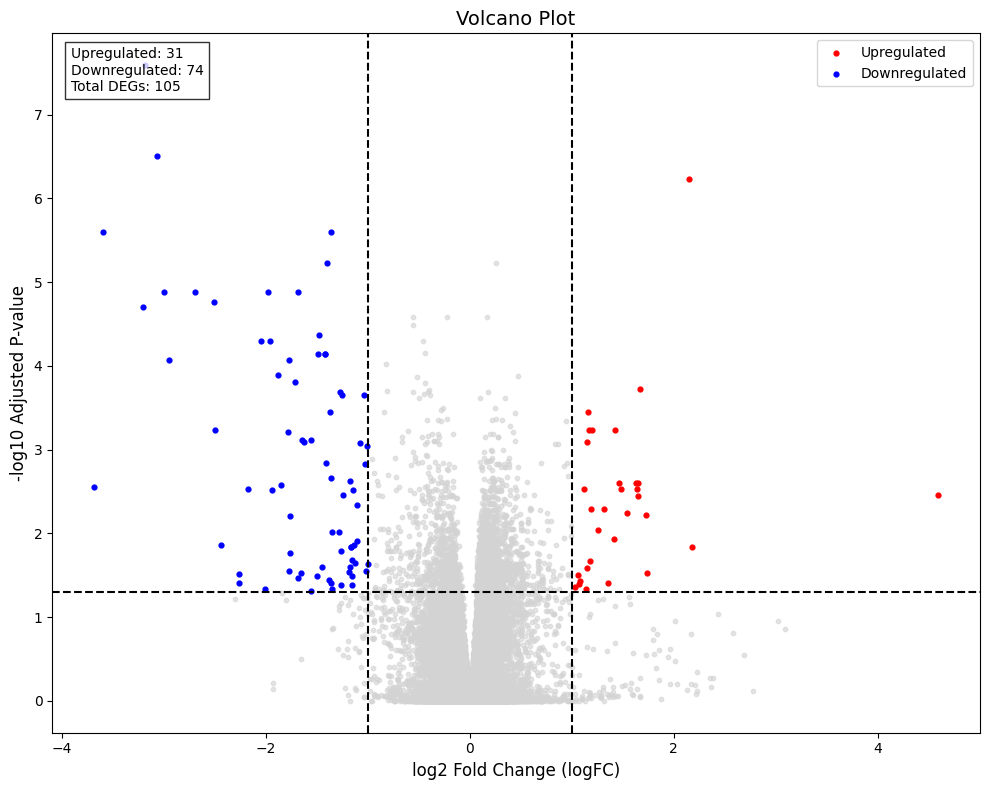


Files saved:
1. Volcano_Plot.png
2. Significant_DEGs.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================
# Install required packages
# ==========================
!pip install pandas matplotlib openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==========================
# Upload Excel file
# ==========================
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# ==========================
# Read Excel file
# ==========================
df = pd.read_csv(filename)

# Clean column names
df.columns = df.columns.astype(str).str.strip()

print("Columns found:")
print(df.columns.tolist())

# ==========================
# Your column names
# ==========================
logfc_col = "logFC"
padj_col = "adj. P. Val"

# Convert to numeric
df[logfc_col] = pd.to_numeric(df[logfc_col], errors="coerce")
df[padj_col] = pd.to_numeric(df[padj_col], errors="coerce")

# Remove missing values
df = df.dropna(subset=[logfc_col, padj_col])

# Remove invalid p-values
df = df[df[padj_col] > 0]

# ==========================
# Calculate -log10(adj.P.Val)
# ==========================
df["minusLog10P"] = -np.log10(df[padj_col])

# ==========================
# Categorize genes
# ==========================
df["Category"] = "Not Significant"

df.loc[
    (df[padj_col] < 0.05) & (df[logfc_col] > 1),
    "Category"
] = "Upregulated"

df.loc[
    (df[padj_col] < 0.05) & (df[logfc_col] < -1),
    "Category"
] = "Downregulated"

# ==========================
# Count DEGs
# ==========================
up = len(df[df["Category"]=="Upregulated"])
down = len(df[df["Category"]=="Downregulated"])
total = up + down

print("\n==========================")
print("DEG SUMMARY")
print("==========================")
print("Upregulated :", up)
print("Downregulated :", down)
print("Total Significant DEGs :", total)

# ==========================
# Save significant genes
# ==========================
sig = df[df["Category"]!="Not Significant"]
sig.to_excel("Significant_DEGs.xlsx", index=False)

# ==========================
# Volcano Plot
# ==========================
plt.figure(figsize=(10,8))

plt.scatter(
    df[df["Category"]=="Not Significant"][logfc_col],
    df[df["Category"]=="Not Significant"]["minusLog10P"],
    color="lightgray",
    s=10,
    alpha=0.6
)

plt.scatter(
    df[df["Category"]=="Upregulated"][logfc_col],
    df[df["Category"]=="Upregulated"]["minusLog10P"],
    color="red",
    s=12,
    label="Upregulated"
)

plt.scatter(
    df[df["Category"]=="Downregulated"][logfc_col],
    df[df["Category"]=="Downregulated"]["minusLog10P"],
    color="blue",
    s=12,
    label="Downregulated"
)

# Threshold lines
plt.axvline(1, color="black", linestyle="--")
plt.axvline(-1, color="black", linestyle="--")
plt.axhline(-np.log10(0.05), color="black", linestyle="--")

plt.xlabel("log2 Fold Change (logFC)", fontsize=12)
plt.ylabel("-log10 Adjusted P-value", fontsize=12)
plt.title("Volcano Plot", fontsize=14)

# Show DEG counts on plot
plt.text(
    0.02,
    0.98,
    f"Upregulated: {up}\nDownregulated: {down}\nTotal DEGs: {total}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()
plt.tight_layout()

plt.savefig("Volcano_Plot.png", dpi=600)

plt.show()

print("\nFiles saved:")
print("1. Volcano_Plot.png")
print("2. Significant_DEGs.xlsx")

files.download("Volcano_Plot.png")
files.download("Significant_DEGs.xlsx")